In [1]:
from scripts.AbstractExperiments import ExperimentRunner, GenerateConfigs
from EnvironmentBuilder.SearchRescue.Rescue import Rescue
import EnvironmentBuilder.SearchRescue.Drawing as SearchRescueDraw
from scripts.TexTables import SaveDataFrameToTexTemplate
from copy import deepcopy
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import math
from scripts.Plotting import *


plt.rcParams.update({
    "font.family": "Charter",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
})
def latex_config_name(name):
    return "$" + name.replace("^0", "^{0}") + "$"

def GenerateTeamConfigs(teams_:list, name_prefix=None):
    configs = {}
    if name_prefix is None:
        name_prefix = f"{len(teams_)}_"
    # Act-Utilitarianism
    con = {"Theories": [["AU", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", "AU"])
    configs[f"{name_prefix}Act-Utilitarianism"] = con

    # Balance
    con = {"Theories": [], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", f"{t}"])
    configs[f"{name_prefix}Separate Theories"] = con

    # Fairness
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Fair"]])
    configs[f"{name_prefix}Fairness"] = con

    # Fairness + Others
    con = {"Theories": [["Fair", "Fairness", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Fair"]])
    configs[f"{name_prefix}Fairness + Separate"] = con

    # Fairness + Act-Utilitarianism
    con = {"Theories": [["Fair", "Fairness", 0], ["AU", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["AU", "Fair"]])
    configs[f"{name_prefix}Fairness + AU"] = con

    # Rawls
    con = {"Theories":[["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls"]])
    configs[f"{name_prefix}Rawls"] = con

    # Rawls + Others
    con = {"Theories": [["Rawls", "Maximin", 0]], "Considerations": []}
    for t in teams_:
        con["Theories"].append([f"{t}", "Utility", 0])
        con["Considerations"].append([f"{t}:wellbeing", [f"{t}", "Rawls"]])
    configs[f"{name_prefix}Rawls + Separate"] = con

    # Rawls + AU
    con = {"Theories": [["Rawls", "Maximin", 0], ["AU", "Utility", 0]], "Considerations": []}
    for t in teams_:
        con["Considerations"].append([f"{t}:wellbeing", ["Rawls", "AU"]])
    configs[f"{name_prefix}Rawls + AU"] = con

    return configs

def MakeTeamWeights(teams_):
    p = [2**i for i in range(0, len(teams_))]
    total = sum(p)
    w = [i / total for i in p]
    o = {}
    for t in teams_:
        for i, t in enumerate(teams_):
            o[f"{t}_hosp_success"] = w[i]
    return o

configurations = [
    "Act-Utilitarianism",
    "Fairness",
    "Rawls",
    "Separate Theories",
    "Fairness + AU",
    "Rawls + AU",
    "Fairness + Separate",
    "Rawls + Separate"
]
a = 0.7
styles = {
    "Act-Utilitarianism":   dict(linestyle="solid", marker="^", color="black", alpha=0.5),
    "Fairness":             dict(linestyle=":", marker="o", color="green", alpha=0.5),
    "Rawls":                dict(linestyle="-.", marker="o", color="red", alpha=0.5),
    "Separate Theories":    dict(linestyle="-", marker="x", color="blue", alpha=a),

    "Fairness + AU":        dict(linestyle=":", marker="^", color="green", alpha=a),
    "Rawls + AU":           dict(linestyle="-.", marker="^", color="red", alpha=a),
    "Fairness + Separate":  dict(linestyle=":", marker="x", color="green", alpha=a),
    "Rawls + Separate":     dict(linestyle="-.", marker="x", color="red", alpha=a),
}

In [ ]:
env_reps = 1
config_list = []
teams = ["red", "blue", "green"]
odds = MakeTeamWeights(teams)
for horizon_ in range(4, 8):
    for b in range(4,8):
        for d in range(0, 5):
            config_list += GenerateConfigs(
                inputConfigs=GenerateTeamConfigs(
                    teams,
                    name_prefix=f"b{b}_h{horizon_}_d{d}_"
                ),
                defaultConfig={
                    "Horizon": horizon_,
                    "Teams": teams, 
                    "unknown_depth": d,
                    "Odds": odds,
                    "Budget": b
                }
            )
# Add Non-moral Cost to all configurations
for c in config_list:
    c["Considerations"].append(["Cost"])
    
er = ExperimentRunner(
    "Rescue",
    config_list,
    MoralPlanner_Location="/../../",
    outFolder="Search"
)

In [3]:
d = er.buildEnvironments()

Written Rescue MMMDP with 25 states and theories [{'Name': 'AU', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h4_d0_Act-Utilitarianism_con0.json

Written Rescue MMMDP with 25 states and theories [{'Name': 'red', 'Type': 'Utility', 'Rank': 0}, {'Name': 'blue', 'Type': 'Utility', 'Rank': 0}, {'Name': 'green', 'Type': 'Utility', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h4_d0_Separate Theories_con0.json

Written Rescue MMMDP with 25 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}].
PATH  /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h4_d0_Fairness_con0.json

Written Rescue MMMDP with 25 states and theories [{'Name': 'Fair', 'Type': 'Fairness', 'Rank': 0}, {'Name': 'red', 'Type': 'Utility', 'Rank': 0}, {'Name': 'blue', 'Type': 'Utilit

In [21]:
er.runPlanner(envRepetitions=env_reps)

Start 1/160 -- /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h4_d0_Act-Utilitarianism_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/c3_h4_d0_Act-Utilitarianism_con0_rep0.json' created successfully!
Start 2/160 -- /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h4_d0_Separate Theories_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTION PLANNER (MEHR-PLAN)
JSON file '/home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/raw/c3_h4_d0_Separate Theories_con0_rep0.json' created successfully!
Start 3/160 -- /home/psiko/Programming/MoralPlanner/Notebooks/SearchRescue/../../Data/Experiments/Rescue/Search/mdps/c3_h4_d0_Fairness_con0.json
THE 2026 MACHINE ETHICS HYPOTHETICAL RETROSPECTIO

In [4]:
er.extractData(1, env_reps)
df = pd.DataFrame(er.data)
df = df.drop(labels=['Configuration Repetition', 'Theories', 'Considerations', 'CQ1 Time', 'CQ2 Time', 'Output Time', 'Solution Reduction Time'],
             axis=1)
df = df.replace(["", "N/A", "NA", "nan", "None"], np.nan)

# ------------------------------------------------------------
# Extract environment parameters BEFORE changing Configuration
# ------------------------------------------------------------

df["communities"] = pd.to_numeric(
    df["Configuration"].str.extract(r"c(\d+)", expand=False),
    errors="coerce"
)

df["Horizon"] = pd.to_numeric(
    df["Configuration"].str.extract(r"_h(\d+)", expand=False),
    errors="coerce"
)

df["unknown_depth"] = pd.to_numeric(
    df["Configuration"].str.extract(r"_d(\d+)", expand=False),
    errors="coerce"
)

df['Configuration'] = df['Configuration'].str.split("_", n=3).str[-1]
df.head(500)

,Configuration,Environment Repetition,Total Time,Heuristic Time,Planning Time,Solution Extraction Time,MEHR Time,Expanded States,BSG States,Average Histories,...,Minimal Non-Acceptability,Number of Minimal Non-Acceptability Policies,Number of Solutions,Total Attacks,Total Reachable Policies,blue:wellbeing,green:wellbeing,red:wellbeing,communities,unknown_depth
0,Act-Utilitarianism,0,220,14,58,146,2,23,25,4,...,0.000000,1,3,6,165,0,1.7143,0,3,0
1,Separate Theories,0,268,24,73,169,2,23,25,4,...,2.000000,3,3,24,165,0,1.7143,0,3,0
2,Fairness,0,210,11,56,141,2,23,25,4,...,0.000000,1,3,6,165,0,0,0.4286,3,0
3,Fairness + Separate,0,205,11,56,135,3,23,25,4,...,2.000000,1,3,30,165,0,0,0.4286,3,0
4,Fairness + AU,0,206,11,57,135,3,23,25,4,...,0.921283,1,3,12,165,0,1.7143,0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,Fairness + Separate,0,273504,185,267161,5163,995,149,290,19,...,2.867190,1,42,3163,-3264118685631612203,1.7143,0,0,3,4
156,Fairness + AU,0,269576,137,263313,5158,968,149,290,19,...,0.875000,1,42,1506,-3264118685631612203,0.875,2.3036,0.875,3,4
157,Rawls,0,273049,130,266806,5133,980,149,290,19,...,0.000000,1,42,1548,-3264118685631612203,1.2679,1.125,1.125,3,4
158,Rawls + Separate,0,271582,130,265167,5211,1074,149,290,19,...,3.000000,4,42,3950,-3264118685631612203,0,3.4286,0,3,4


## Extract Policy Level Results


In [7]:
wellbeing_cols = [f"{t}:wellbeing" for t in teams]
worth_df = pd.DataFrame(er.GetWorthData(worth_tags=[f"{t}:wellbeing" for t in teams], envRepetitions=env_reps))

worth_df = worth_df.drop(columns=["Configuration Repetition"])
worth_df["communities"] = pd.to_numeric(worth_df["Configuration"].str.extract(r"c(\d+)", expand=False),errors="coerce")

worth_df["Horizon"] = pd.to_numeric(worth_df["Configuration"].str.extract(r"_h(\d+)", expand=False), errors="coerce")

worth_df["unknown_depth"] = pd.to_numeric(worth_df["Configuration"].str.extract(r"_d(\d+)", expand=False), errors="coerce")

worth_df['Configuration'] = worth_df['Configuration'].str.split("_", n=3).str[-1]

worth_df[wellbeing_cols] = worth_df[wellbeing_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

# NaN values are ignored. Thus, an experiment with two communities only uses
# 0:wellbeing and 1:wellbeing.
worth_df["Policy wellbeing minimum"] = worth_df[wellbeing_cols].min(axis=1, skipna=True)

worth_df["Policy wellbeing maximum"] = worth_df[wellbeing_cols].max(axis=1, skipna=True)

worth_df["Policy wellbeing average"] = worth_df[wellbeing_cols].mean(axis=1, skipna=True)

# ddof=0 gives the population standard deviation.
worth_df["Policy wellbeing standard deviation"] = worth_df[wellbeing_cols].std(axis=1, skipna=True, ddof=0 )

worth_df

,Configuration,Environment Repetition,Horizon,Policy Index,Non-acceptability,nacc_AU,red:wellbeing,blue:wellbeing,green:wellbeing,nacc_red,nacc_blue,nacc_green,nacc_Fair,nacc_Rawls,communities,unknown_depth,Policy wellbeing minimum,Policy wellbeing maximum,Policy wellbeing average,Policy wellbeing standard deviation
0,Act-Utilitarianism,0,4,0,0.0,0.0,0.0000,0.0000,1.7143,NaN,NaN,NaN,NaN,NaN,3,0,0.000,1.7143,0.571433,0.808129
1,Separate Theories,0,4,0,2.0,NaN,0.0000,0.0000,1.7143,1.0,1.0,0.0,NaN,NaN,3,0,0.000,1.7143,0.571433,0.808129
2,Separate Theories,0,4,1,2.0,NaN,0.0000,0.8571,0.0000,1.0,0.0,1.0,NaN,NaN,3,0,0.000,0.8571,0.285700,0.404041
3,Separate Theories,0,4,2,2.0,NaN,0.4286,0.0000,0.0000,0.0,1.0,1.0,NaN,NaN,3,0,0.000,0.4286,0.142867,0.202044
4,Fairness,0,4,0,0.0,NaN,0.4286,0.0000,0.0000,NaN,NaN,NaN,0.0,NaN,3,0,0.000,0.4286,0.142867,0.202044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
216,Rawls + Separate,0,7,1,3.0,NaN,0.0000,1.7143,0.0000,1.0,0.0,1.0,NaN,1.0,3,4,0.000,1.7143,0.571433,0.808129
217,Rawls + Separate,0,7,2,3.0,NaN,1.2321,0.8750,0.8750,0.0,1.0,1.0,NaN,1.0,3,4,0.875,1.2321,0.994033,0.168339
218,Rawls + Separate,0,7,3,3.0,NaN,1.1250,1.2679,1.1250,1.0,1.0,1.0,NaN,0.0,3,4,1.125,1.2679,1.172633,0.067364
219,Rawls + AU,0,7,0,1.0,1.0,1.1250,1.2679,1.1250,NaN,NaN,NaN,NaN,0.0,3,4,1.125,1.2679,1.172633,0.067364


## Policy-level and depth-level wellbeing summaries

**policy_df** copies **worth_df** and calculates minimum, maximum, mean, and population standard deviation across the available community wellbeing columns for every policy.

**depth_wellbeing_summary** then averages those four policy statistics by Configuration and unknown_depth. It is the compact table used to inspect how wellbeing distribution changes with search depth.


In [8]:
policy_df = worth_df.copy()

wellbeing_cols = [
    column for column in policy_df.columns
    if column.endswith(":wellbeing")
]
if not wellbeing_cols:
    raise ValueError("No community wellbeing columns were found.")

policy_df[wellbeing_cols] = policy_df[wellbeing_cols].apply(
    pd.to_numeric, errors="coerce"
)

metric_columns = {
    "Minimum": "Policy wellbeing minimum",
    "Maximum": "Policy wellbeing maximum",
    "Mean": "Policy wellbeing mean",
    "Standard deviation": "Policy wellbeing standard deviation",
}

policy_df[metric_columns["Minimum"]] = policy_df[wellbeing_cols].min(axis=1, skipna=True)
policy_df[metric_columns["Maximum"]] = policy_df[wellbeing_cols].max(axis=1, skipna=True)
policy_df[metric_columns["Mean"]] = policy_df[wellbeing_cols].mean(axis=1, skipna=True)
policy_df[metric_columns["Standard deviation"]] = policy_df[wellbeing_cols].std(
    axis=1, skipna=True, ddof=0
)

depth_wellbeing_summary = (
    policy_df
    .dropna(subset=["unknown_depth"])
    .groupby(["Configuration", "unknown_depth"], observed=True)[
        list(metric_columns.values())
    ]
    .mean()
    .reset_index()
    .sort_values(["Configuration", "unknown_depth"])
)
depth_wellbeing_summary.round(4)

,Configuration,unknown_depth,Policy wellbeing minimum,Policy wellbeing maximum,Policy wellbeing mean,Policy wellbeing standard deviation
0,Act-Utilitarianism,0,0.0000,2.5714,0.8571,1.2122
1,Act-Utilitarianism,1,0.5000,1.9286,0.9762,0.6734
2,Act-Utilitarianism,2,0.7500,1.6786,1.0595,0.4377
3,Act-Utilitarianism,3,0.8125,1.6339,1.0863,0.3872
4,Act-Utilitarianism,4,0.8125,1.6339,1.0863,0.3872
5,Fairness,0,0.1174,0.3265,0.2126,0.0947
6,Fairness,1,0.5051,0.6990,0.5833,0.0875
7,Fairness,2,0.8750,0.9822,0.9107,0.0505
8,Fairness,3,0.9375,1.0178,0.9643,0.0379
9,Fairness,4,0.9375,1.0178,0.9643,0.0379


### Overview: compare depth levels within each wellbeing statistic

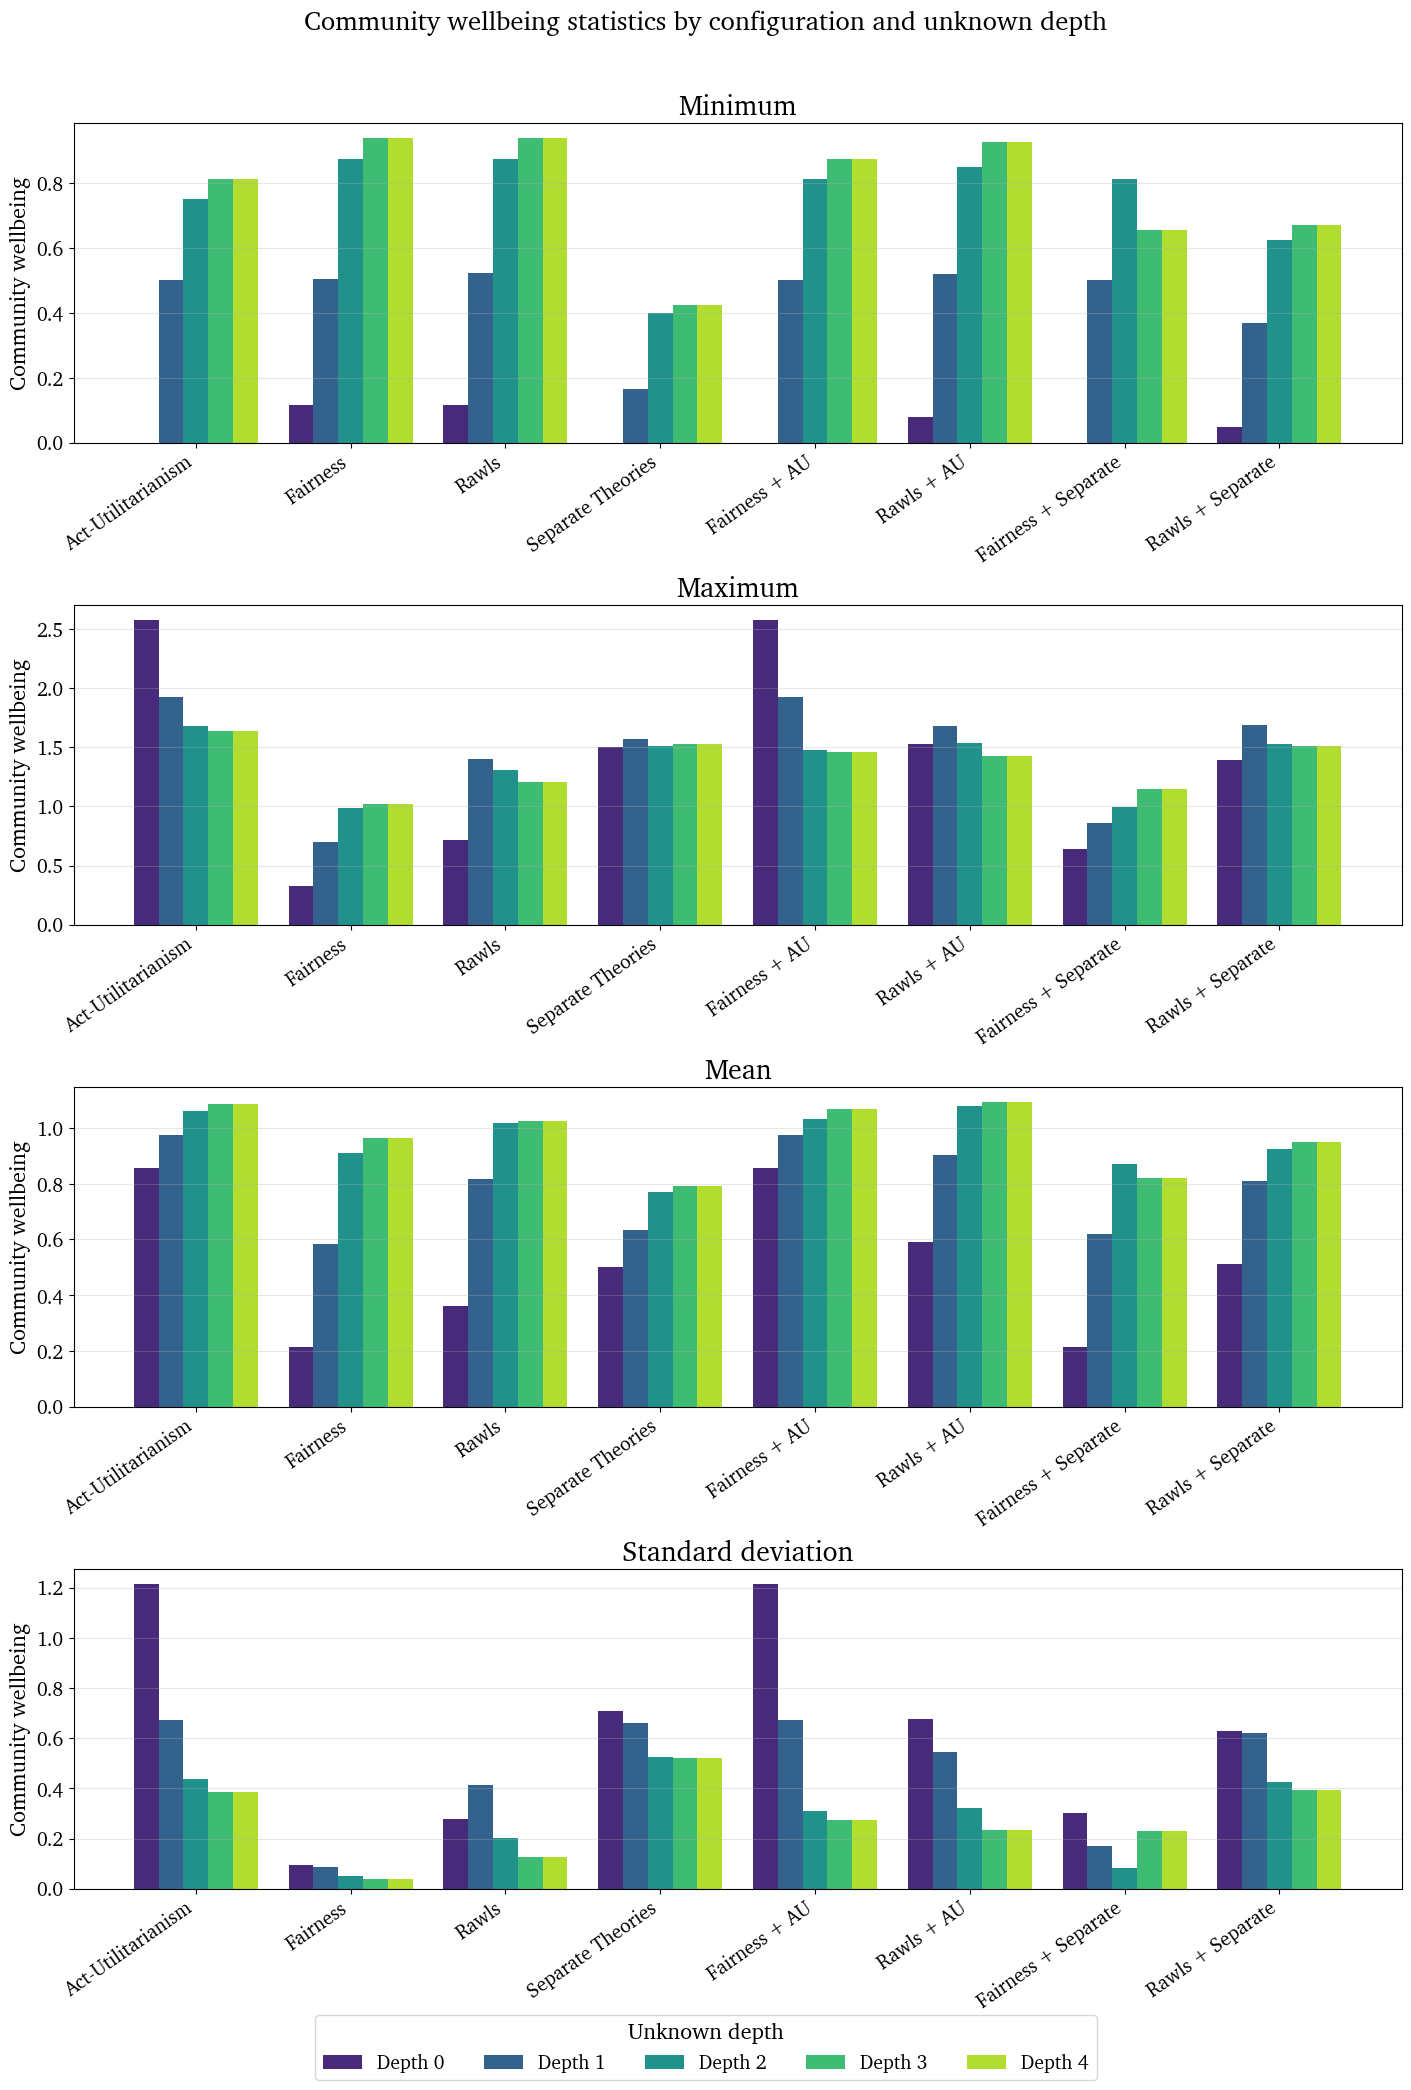

In [ ]:
configuration_order = [
    config for config in configurations
    if config in depth_wellbeing_summary["Configuration"].unique()
]
depth_order = sorted(
    depth_wellbeing_summary["unknown_depth"].dropna().unique()
)
depth_colours = plt.cm.viridis(np.linspace(0.12, 0.88, len(depth_order)))

fig, axes = plt.subplots(4, 1, figsize=(14, 20), constrained_layout=True)
x = np.arange(len(configuration_order))
bar_width = 0.8 / max(len(depth_order), 1)

for ax, (metric_label, metric_column) in zip(axes.flat, metric_columns.items()):
    pivot = depth_wellbeing_summary.pivot(
        index="Configuration",
        columns="unknown_depth",
        values=metric_column,
    ).reindex(index=configuration_order, columns=depth_order)

    for depth_index, depth in enumerate(depth_order):
        positions = x + (depth_index - (len(depth_order) - 1) / 2) * bar_width
        ax.bar(
            positions,
            pivot[depth].to_numpy(),
            width=bar_width,
            color=depth_colours[depth_index],
            label=f"Depth {int(depth)}",
        )

    ax.set_title(metric_label)
    ax.set_xticks(x)
    ax.set_xticklabels(configuration_order, rotation=35, ha="right")
    ax.set_ylabel("Community wellbeing")
    ax.grid(axis="y", alpha=0.3)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Unknown depth", loc="outside lower center", ncols=len(depth_order))
fig.suptitle("Community wellbeing statistics by configuration and unknown depth", y=1.04)
plt.show()
#plt.savefig('')